In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


Ми тестуємо  підписку Група А: цим користувачам ми пропонуємо купити підписку за $4.99, щоб отримати доступ до преміум-функцій застосунку
Група В: пропонуємо ту ж підписку, але з припискою про те, що це пропозиція зі знижкою 50%

Ми хочемо підняти конверсію в  підписку

Наша гіпотеза така  в варіанті b конверсія збільшиться

Включаємо  нових  користувачів що встановили додаток

In [3]:
test=pd.read_csv("C:/Users/Влад/Downloads/_ab_test_data.csv")

In [4]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     19998 non-null  object
 1   timestamp   19998 non-null  object
 2   test_group  19998 non-null  object
 3   conversion  19998 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 625.1+ KB


In [6]:
test.groupby( 'test_group'). describe()



timestamp                                 \
               count                           mean   
test_group                                            
a              10013  2023-07-14 02:34:29.519821312   
b               9985  2023-07-13 21:37:07.888925952   

                                                                       \
                                   min                            25%   
test_group                                                              
a           2023-07-03 01:46:14.688840  2023-07-08 13:48:52.874817024   
b           2023-07-03 01:42:34.033708  2023-07-08 08:08:48.495631104   

                                                                          \
                                      50%                            75%   
test_group                                                                 
a           2023-07-14 03:49:36.002731008  2023-07-19 14:06:28.688054016   
b           2023-07-13 19:14:14.073116928  2023-07-19 09:59:58.771382016   

                                            conversion                      \
                                   max  std      count      mean  min  25%   
test_group                                                                   
a           2023-07-25 01:41:19.152664  NaN    10013.0  0.061021  0.0  0.0   
b           2023-07-25 01:35:59.130658  NaN     9985.0  0.089034  0.0  0.0   

                                     
            50%  75%  max       std  
test_group                           
a           0.0  0.0  1.0  0.239380  
b           0.0  0.0  1.0  0.284806

In [5]:
test ['timestamp']=pd.to_datetime(test ['timestamp'])

In [7]:
test.groupby( 'test_group')['user_id'].nunique()



test_group
a    10013
b     9985
Name: user_id, dtype: int64

Кількість користуваів в  групах

In [8]:
test.groupby( 'test_group')['conversion'].sum()



test_group
a    611
b    889
Name: conversion, dtype: int64

In [ ]:
кількість людей які купили підписку в групах

In [9]:
test.groupby( 'test_group')['conversion'].mean()

test_group
a    0.061021
b    0.089034
Name: conversion, dtype: float64

відсоткове значення  конверсій в групі а 6.1 % в групі b 8.9%

In [10]:
test.timestamp.min()

Timestamp('2023-07-03 01:42:34.033708')

Дата старту тесту

In [11]:
test.timestamp.max()

Timestamp('2023-07-25 01:41:19.152664')

дата завершення тесту

In [12]:
test.timestamp.max()-test.timestamp.min()

Timedelta('21 days 23:58:45.118956')

тривалість тесту

In [13]:
alpha = 0.05

statistic, pvalue = stats.ttest_ind(test[test['test_group'] == 'b']['conversion'],
                                     test[test['test_group'] == 'a']['conversion'],
                                     alternative='greater')

print(f"t-statistic: {round(statistic, 2)}, p-value: {round(pvalue, 2)}")

if pvalue < alpha:
    print("The difference is statistically significant, Null Hypothesis is rejected.")
else:
    print("The difference is not statistically significant, Null Hypothesis cannot be rejected.")


t-statistic: 7.53, p-value: 0.0
The difference is statistically significant, Null Hypothesis is rejected.


цей t test  показує що наша нульова гіпотеза може бути відхиленою

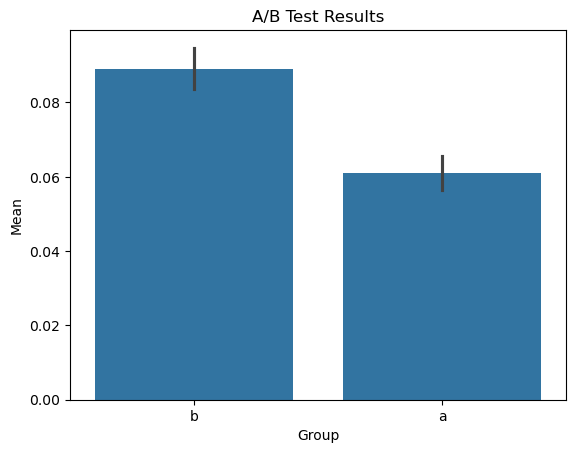

In [24]:
sns.barplot(x=test['test_group'],
            y=test['conversion'],
            errorbar=('ci', 95))  # Confidence Intervals

plt.title('A/B Test Results')
plt.xlabel('Group')
plt.ylabel('Mean')
plt.savefig('D:/Python/ab_test_results.png', dpi=300, bbox_inches='tight')
plt.show()


Група b має вищу середню величину (трохи більше 0.08), ніж група a (трохи більше 0.06).
Це може свідчити про те, що варіант b працює краще

In [14]:
test = test.sample(frac=1).reset_index(drop=True)
cumulative_metric_a = test[test['test_group'] == 'a']['conversion'].expanding().mean().reset_index(drop=True)
cumulative_metric_b = test[test['test_group'] == 'b']['conversion'].expanding().mean().reset_index(drop=True)


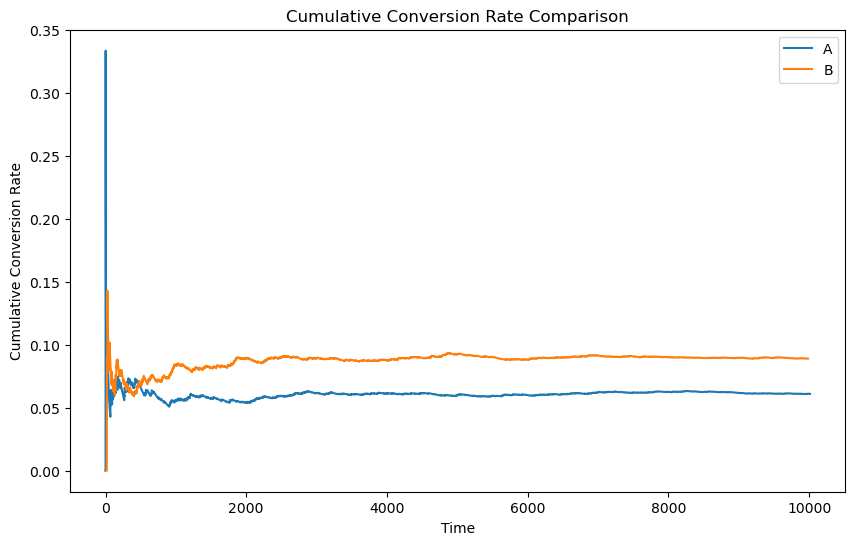

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(cumulative_metric_a, label='A')
plt.plot(cumulative_metric_b, label='B')

plt.title('Cumulative Сonversion Rate Comparison')
plt.xlabel('Time')
plt.ylabel('Cumulative Сonversion Rate')

plt.legend()
plt.show()

На самому початку обидві групи мають різкий стрибок, але група A спочатку показує вищу конверсію.
Згодом ситуація змінюється: група B стабільно випереджає групу A за накопиченою конверсією.
Ця перевага зберігається протягом усього періоду тестування (до 10 000 одиниць часу).Хоча група A мала кращий старт, довгостроково варіант B показує кращу ефективність.	Це може свідчити про те, що користувачі краще реагують на варіант B з часом — можливо, він більш  викликає довіру.


ми досягли успіху конверсія в групі b вища, тому приймаємо альтернативний варіант до імплементації додаткові метрики не змінились